# Predictor layers

In this notebook, we prepare the layers of the predictors later used for Random Forest modeling of post-fire vegetation recovery. We load the data, process it if necessary, and align it with the study area grid created in a previous notebook.

We include the following predictors:
- the 2-month and 2-year median [pre-fire EVI](#Pre-fire-EVI)
- the fire history

## Preparation

In [1]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
from rasterio.enums import Resampling
from rasterio import features
import numpy as np
import glob

In [2]:
from custom_functions import sel_bounds

In [3]:
study_area = rxr.open_rasterio('output-data/study-area/study_area_kalimantan.tif')

## Post-fire EVI

In [1]:
!gdalbuildvrt input-data/EVI/Landsat_Post_Fire_EVI.vrt $(find input-data/EVI -name "Landsat_Post_Fire_EVI*.tif")

0...10...20...30...40...50...60...70...80...90...100 - done.


In [4]:
post_fire_evi = rxr.open_rasterio('input-data/EVI/Landsat_Post_Fire_EVI.vrt')

In [6]:
post_fire_evi = sel_bounds(post_fire_evi, study_area)

In [7]:
post_fire_evi_reproj = post_fire_evi.rio.reproject_match(study_area, resampling=Resampling.average)

In [9]:
post_fire_evi_reproj.rio.to_raster('output-data/predictor-layers/post-fire-evi.tif')

## Pre-fire EVI

We used both a 2-month and 2-year pre-fire median EVI, to capture both an immediate snapshot of vegetation just before the fire as well as a longer-term indicator of vegetation at any given place.

The two datasets were obtained via Google Earth Engine (corresponding scripts can be found in repository), using Landsat 8 data (30m resolution)

In [7]:
# build virtual rasters
!gdalbuildvrt input-data/EVI/Landsat_MedianEVI_Jun_Jul.vrt $(find input-data/EVI -name "Landsat_MedianEVI_Jun_Jul*.tif")
!gdalbuildvrt input-data/EVI/Landsat_MedianEVI_2013_2015.vrt $(find input-data/EVI -name "Landsat_MedianEVI_2012_2015*.tif")

# get all relevant filepaths
files_2month = sorted(glob.glob("input-data/EVI/Landsat_MedianEVI_Jun_Jul*.tif"))
files_2year = sorted(glob.glob("input-data/EVI/Landsat_MedianEVI_2012_2015*.tif"))

# load tiles together
evi_2year = xr.open_mfdataset(files_2year, chunks={"x": 1024, "y": 1024}).rename({'band_data': 'EVI_2year_pre'})
evi_2month = xr.open_mfdataset(files_2month, chunks={"x": 1024, "y": 1024}).rename({'band_data': 'EVI_2month_pre'})

# combine in one dataset (since grids already align)
evi_pre = evi_2year.merge(evi_2month, compat='no_conflicts')

# crop to study area
evi_pre_kalimantan = sel_bounds(evi_pre, study_area)

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.


In [8]:
# reproject to match study area raster -> this will be the xarray dataset where we collect all predictor layers
predictor_stack = evi_pre_kalimantan.rio.reproject_match(
    study_area, 
    resampling=Resampling.average) # coarsen (30m to 250m), therefore take mean

In [ ]:
# save
evi_pre_kalimantan_reproj.EVI_2month_pre.rio.to_raster('output-data/predictor-layers/evi_2month_pre.tif')
evi_pre_kalimantan_reproj.EVI_2year_pre.rio.to_raster('output-data/predictor-layers/evi_2year_pre.tif')

In [ ]:
evi_pre_kalimantan_reproj.EVI_2month_pre.plot()

## Fire history

This layer indicates fire frequency, measured as the total number of fires in a given pixel between 2001 (start of the MODIS fire alerts dataset) and July 2015 (before our fire season).

For this purpose, we only used fire alerts with confidence > 70%, as defined in the first notebook.

In [9]:
# load fire alert points until July 2015 (created and exported in 1_study_area.ipynb)
fires_before = gpd.read_file('output-data/fire-alerts/fire_alerts_before.shp')

In [10]:
from rasterio import features
from rasterio.enums import MergeAlg
import numpy as np

# project to metric CRS
fires_proj = fires_before.to_crs("EPSG:3857")

# buffer 500 m
fires_proj["geometry"] = fires_proj.buffer(500, cap_style='square')

# back to study CRS
fires_buffered = fires_proj.to_crs(predictor_stack.rio.crs)

transform = study_area.rio.transform()
out_shape = study_area.rio.shape

# rasterize all at once and SUM overlaps
fire_count_array = features.rasterize(
    ((geom, 1) for geom in fires_buffered.geometry),
    out_shape=out_shape,
    transform=transform,
    all_touched=True, # any time pixel is touched by a buffer count as burn
    merge_alg=MergeAlg.add,
    dtype="uint16"
)

In [11]:
# add to merged stack
predictor_stack["prev_fire_count"] = xr.DataArray(
    fire_count_array,
    dims=["y", "x"],
    coords={"y": predictor_stack.y, "x": predictor_stack.x},
)

In [ ]:
predictor_stack.prev_fire_count.plot()

## Distance to intact forest

In [32]:
# load forest data (exported from 1_study_area_identification.ipynb)
forest = rxr.open_rasterio('output-data/forest/kalimantan_forest_2015.tif')
forest = forest.rio.write_crs(4326)

In [49]:
# compute distance

# set values inside study area to 0 (because they will no longer be intact forest after the fires)
forest_no_study_area = xr.where(study_area == 1, 0, forest)

# reproject to CRS in m (Pseudo-Mercator)
forest_no_study_area_reproj = forest_no_study_area.rio.write_crs(4326).rio.reproject(3857, resampling=Resampling.nearest)

In [51]:
from scipy.ndimage import distance_transform_edt

# compute distance raster (meters)
pixel_size = abs(forest_no_study_area_reproj.rio.resolution()[0])
dist = distance_transform_edt(forest_no_study_area_reproj.values == 0) * pixel_size

# bring values into array format
dist_da = xr.DataArray(
    dist,
    coords=forest_no_study_area_reproj.coords,
    dims=forest_no_study_area_reproj.dims
).rio.write_crs(forest_no_study_area_reproj.rio.crs)

In [55]:
dist_da_lim = xr.where(dist_da>5000,5000, dist_da)

In [58]:
# reproject

forest_dist = dist_da_lim.rio.write_crs(3857).rio.reproject_match(
    study_area,
    resampling=Resampling.bilinear)

In [60]:
# mask with study area
forest_dist_study_area = xr.where(study_area == 1, forest_dist, np.nan).rio.write_crs(4326)

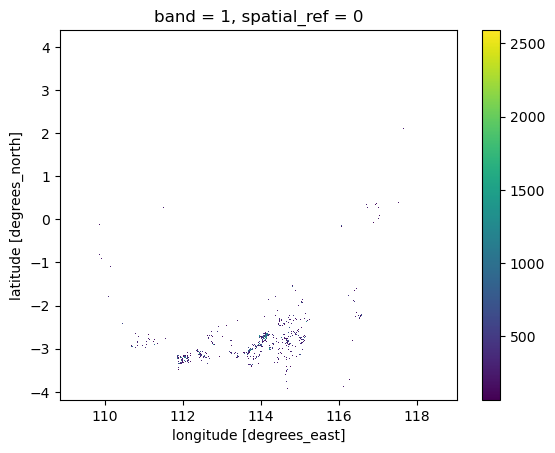

In [61]:
forest_dist_study_area.plot()

In [62]:
# export 
forest_dist_study_area.rio.to_raster('output-data/predictor-layers/forest-dist.tif')

## Distance to drainage channels

used as a proxy for water table depth (closer to drainage channel means lower water table)

using raster files of drainage canals in Southeast Asia from XXX (link)

In [ ]:
# build virtual raster from multiple files
!gdalbuildvrt input-data/drainage-canals/drainage_canals.vrt $(find input-data/drainage-canals -name "*.tif")                                                               

This virtual raster is then imported into QGIS where it is masked with the (vectorized) study area, and coarsen from a 5 to a 50 m spatial resolution. QGIS was used because this step was too computationally expensive for Jupyter notebooks.

In [5]:
# load resampled and data
drainage_50m = rxr.open_rasterio('input-data/drainage-canals/drainage_canals_study_area_50m.tif')

In [9]:
from scipy.ndimage import distance_transform_edt

# compute distance raster (meters)
pixel_size = abs(drainage_50m.rio.resolution()[0])
dist = distance_transform_edt(drainage_50m.values == 0) * pixel_size

# bring values into array format
dist_da = xr.DataArray(
    dist,
    coords=drainage_50m.coords,
    dims=drainage_50m.dims
).rio.write_crs(drainage_50m.rio.crs)

In [23]:
# set values above 10000 (10km) to 10000 (higher distance doesn't make difference anymore)
dist_da = xr.where(dist_da > 10000, 10000, dist_da).rio.write_crs(drainage_50m.rio.crs)

In [24]:
# reproject
dist_da_reproj = dist_da.rio.reproject_match(
    study_area, # project to EPSG 4326 with resolution 250m
    resampling=Resampling.average) # 250m pixel will have average value of 50m pixels it contains

In [28]:
# export 
dist_da_reproj.rio.to_raster('output-data/predictor-layers/drainage-dist.tif')

In [18]:
# # load distance raster computed in QGIS (50m resolution)
# drainage_dist_qgis = rxr.open_rasterio('input-data/drainage-canals/drainage-distance-50m-qgis.tif')

# # reproject
# dist_da_reproj_qgis = drainage_dist_qgis.rio.reproject_match(
#     predictor_stack, # project to EPSG 4326 with resolution 250m
#     resampling=Resampling.average) # 250m pixel will have average value of 50m pixels it contains

In [29]:
# export 
# dist_da_reproj_qgis.rio.to_raster('output-data/predictor-layers/drainage-dist-qgis.tif')

## Final

In [ ]:
# set all values outside study area to NaN

#ds = ds.where(ds['study_area'] == 1)
